In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
# import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
# from keras.models import Sequential
# from keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


In [8]:
# Load the dataset
all_available = pd.read_csv(r'E:\Manoj_honors\Merged_Data(Spatio-temporal).csv')
all_available.dropna(inplace=True)
# Prepare the feature set and target variables
X = all_available[['Station_ID','Ozone','NO2_prev_day', 'PM2.5_prev_day', 'Ozone_prev_day',
                                'NO2_prev_week', 'PM2.5_prev_week', 'Ozone_prev_week', 'Spatial_Avg_PM2.5',
                                'Spatial_Avg_Ozone', 'Spatial_Avg_NO2']]
y = all_available[['PM2.5', 'NO2']]  # Target variables: NO2 and Ozone
# Convert 'Time' to numeric if it's in datetime format
# X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold for both targets
mse_scores_pm25 = []
mae_scores_pm25 = []
r2_scores_pm25 = []
mape_scores_pm25 = []
nrmse_scores_pm25 = []

mse_scores_no2 = []
mae_scores_no2 = []
r2_scores_no2 = []
mape_scores_no2 = []
nrmse_scores_no2 = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Split predictions back into PM2.5 and Ozone
    y_pred_pm25 = y_pred[:, 0]
    y_pred_no2 = y_pred[:, 1]

    # Calculate evaluation metrics for PM2.5
    mse_pm25 = mean_squared_error(y_test['PM2.5'], y_pred_pm25)
    mae_pm25 = mean_absolute_error(y_test['PM2.5'], y_pred_pm25)
    r2_pm25 = r2_score(y_test['PM2.5'], y_pred_pm25)
    mape_pm25 = np.mean(np.abs((y_test['PM2.5'] - y_pred_pm25) / y_test['PM2.5'])) * 100
    nrmse_pm25 = np.sqrt(mse_pm25) / (y_test['PM2.5'].max() - y_test['PM2.5'].min())

    # Calculate evaluation metrics for Ozone
    mse_no2 = mean_squared_error(y_test['NO2'], y_pred_no2)
    mae_no2 = mean_absolute_error(y_test['NO2'], y_pred_no2)
    r2_no2 = r2_score(y_test['NO2'], y_pred_no2)
    mape_no2 = np.mean(np.abs((y_test['NO2'] - y_pred_no2) / y_test['NO2'])) * 100
    nrmse_no2 = np.sqrt(mse_no2) / (y_test['NO2'].max() - y_test['NO2'].min())

    # Append metrics for PM2.5
    mse_scores_pm25.append(mse_pm25)
    mae_scores_pm25.append(mae_pm25)
    r2_scores_pm25.append(r2_pm25)
    mape_scores_pm25.append(mape_pm25)
    nrmse_scores_pm25.append(nrmse_pm25)

    # Append metrics for Ozone
    mse_scores_no2.append(mse_no2)
    mae_scores_no2.append(mae_no2)
    r2_scores_no2.append(r2_no2)
    mape_scores_no2.append(mape_no2)
    nrmse_scores_no2.append(nrmse_no2)

# Calculate mean and standard deviation for each metric for PM2.5
mean_mse_pm25 = np.mean(mse_scores_pm25)
std_mse_pm25 = np.std(mse_scores_pm25)
mean_mae_pm25 = np.mean(mae_scores_pm25)
std_mae_pm25 = np.std(mae_scores_pm25)
mean_r2_pm25 = np.mean(r2_scores_pm25)
std_r2_pm25 = np.std(r2_scores_pm25)
mean_mape_pm25 = np.mean(mape_scores_pm25)
std_mape_pm25 = np.std(mape_scores_pm25)
mean_nrmse_pm25 = np.mean(nrmse_scores_pm25)
std_nrmse_pm25 = np.std(nrmse_scores_pm25)

# Calculate mean and standard deviation for each metric for Ozone
mean_mse_no2 = np.mean(mse_scores_no2)
std_mse_no2 = np.std(mse_scores_no2)
mean_mae_no2 = np.mean(mae_scores_no2)
std_mae_no2 = np.std(mae_scores_no2)
mean_r2_no2 = np.mean(r2_scores_no2)
std_r2_no2 = np.std(r2_scores_no2)
mean_mape_no2 = np.mean(mape_scores_no2)
std_mape_no2 = np.std(mape_scores_no2)
mean_nrmse_no2 = np.mean(nrmse_scores_no2)
std_nrmse_no2 = np.std(nrmse_scores_no2)

# Print evaluation metrics for PM2.5
print(f"PM2.5 - Mean Squared Error: {round(mean_mse_pm25, 2)} ± {round(std_mse_pm25, 2)}")
print(f"PM2.5 - Mean Absolute Error: {round(mean_mae_pm25, 2)} ± {round(std_mae_pm25, 2)}")
print(f"PM2.5 - R^2 Score: {round(mean_r2_pm25, 2)} ± {round(std_r2_pm25, 2)}")
print(f"PM2.5 - Mean Absolute Percentage Error: {round(mean_mape_pm25, 2)}% ± {round(std_mape_pm25, 2)}%")
print(f"PM2.5 - Normalized RMSE: {round(mean_nrmse_pm25, 4)} ± {round(std_nrmse_pm25, 4)}")

# Print evaluation metrics for Ozone
print(f"NO2 - Mean Squared Error: {round(mean_mse_no2, 2)} ± {round(std_mse_no2, 2)}")
print(f"NO2 - Mean Absolute Error: {round(mean_mae_no2, 2)} ± {round(std_mae_no2, 2)}")
print(f"NO2 - R^2 Score: {round(mean_r2_no2, 2)} ± {round(std_r2_no2, 2)}")
print(f"NO2 - Mean Absolute Percentage Error: {round(mean_mape_no2, 2)}% ± {round(std_mape_no2, 2)}%")
print(f"NO2 - Normalized RMSE: {round(mean_nrmse_no2, 4)} ± {round(std_nrmse_no2, 4)}")

# import joblib
# model_output_path = r'D:\Manoj_Honors\random_forest_model_PM2.5_Ozone.joblib'
# joblib.dump(rf, model_output_path)

# print(f"Model saved to {model_output_path}")


KeyboardInterrupt: 

In [2]:
import pandas as pd
import joblib

# File paths
model_path = r'D:\Manoj_Honors\random_forest_model_PM2.5_Ozone.joblib'  # Assuming one model for both PM2.5 and NO2
input_csv_path = r"D:\Manoj_Honors\Imputed_Predictions(Univariate,(O3,PM2.5)).csv"
output_csv_path = r"D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv"

# Load the model
with open(model_path, 'rb') as model_file:
    rf_model = joblib.load(model_file)

# Load the input data
df = pd.read_csv(input_csv_path)

# Check the required columns
required_columns = ['Time', 'Lat', 'Lon', 'NO2', 'PM2.5', 'Average_NO2_t-1', 'Ozone']
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Identify rows where both PM2.5 and NO2 are missing and Ozone is available
mask_missing_pm25_and_no2 = df['Ozone'].isna() & df['PM2.5'].isna() & df['NO2'].notna()

# Count rows with missing PM2.5 and NO2
missing_count = mask_missing_pm25_and_no2.sum()
print(f"Number of rows with missing PM2.5 and NO2 (but Ozone available): {missing_count}")

# Filter the rows where both PM2.5 and NO2 are missing and Ozone is available
rows_to_impute = df[mask_missing_pm25_and_no2]

# Prepare the features for imputation
X_to_impute = rows_to_impute[['Time', 'Lat', 'Lon', 'NO2','Average_NO2_t-1']]

# Convert 'Time' to seconds since epoch (as the model was likely trained on this format)
X_to_impute['Time'] = pd.to_datetime(X_to_impute['Time'], errors='coerce').astype('int64') // 10**9

# Ensure the columns are in the same order as during model training
train_columns = ['Time', 'Lat', 'Lon', 'NO2','Average_NO2_t-1']
X_to_impute = X_to_impute[train_columns]

# Impute the missing values using the model
imputed_values = rf_model.predict(X_to_impute)

# Assign the imputed values back to the appropriate columns
# Assume the model returns imputed values for both PM2.5 and NO2
df.loc[mask_missing_pm25_and_no2, ['Ozone', 'PM2.5']] = imputed_values.reshape(-1, 2)

# Save the updated dataframe with imputed values to a new CSV
df.to_csv(output_csv_path, index=False)

print(f"Imputed rows and saved the updated data to {output_csv_path}")


Number of rows with missing PM2.5 and NO2 (but Ozone available): 4271


C:\Users\Faculty\AppData\Local\Temp\ipykernel_16112\1953572743.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_to_impute['Time'] = pd.to_datetime(X_to_impute['Time'], errors='coerce').astype('int64') // 10**9


Imputed rows and saved the updated data to D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv


In [2]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# import pickle

# with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
#     pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_19924\1320764467.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_19924\1320764467.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 712.44 ± 16.49
Mean Absolute Error: 15.13 ± 0.06
R^2 Score: 0.91 ± 0.0
Mean Absolute Percentage Error: 44.38% ± 2.46%
Normalized RMSE: 0.0268 ± 0.0003


In [27]:
import pandas as pd

df = pd.read_csv(r'D:\Manoj_Honors\Merged_Data_avg.csv')
print(df.columns)


# Count non-null values of PM2.5 for each station
station_pm25_counts = df.groupby('Station_ID')['PM2.5'].count()

# Get the station with the highest count of non-null PM2.5 values
station_with_fewest_nulls = station_pm25_counts.idxmax()

print(f"Station with the fewest null values in PM2.5: {station_with_fewest_nulls}")
print(f"Non-null PM2.5 counts for each station:\n{station_pm25_counts}")

Index(['Time', 'Station_ID', 'NO2', 'PM2.5', 'Ozone', 'Lat', 'Lon', 'Date',
       'Average_PM2.5_t-1', 'Average_Ozone_t-1', 'Average_NO2_t-1'],
      dtype='object')
Station with the fewest null values in PM2.5: 11
Non-null PM2.5 counts for each station:
Station_ID
0     29477
1     25343
2     28498
3     28282
4     29467
5     28911
6     29101
7     12110
8     27968
9     29807
10    29935
11    30143
12    27839
13    28784
14    29171
15    29512
16    10516
17    29841
18    28914
19    27815
20    29138
21    28862
22    29090
23    29912
24    29080
25    17137
26    28633
27    29846
28    29128
29    29321
30    29606
31    29327
32    27429
33    28998
34    29521
35    29174
36    29848
37    29204
38    19701
39    28856
Name: PM2.5, dtype: int64


<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_3708\3296856471.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('MAE ($\mu g/m^3$) ', fontweight='bold')


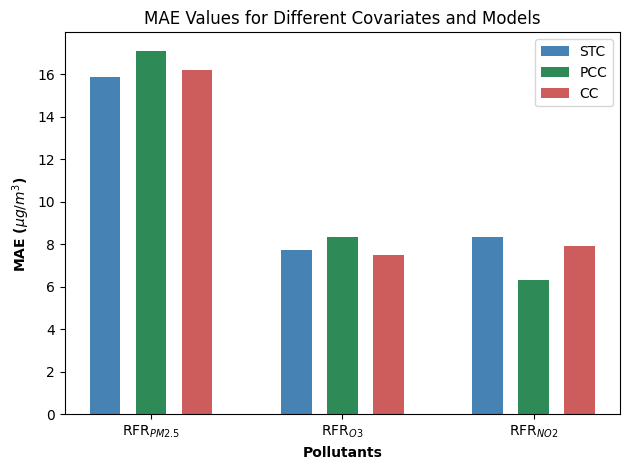

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['PM2.5', 'Ozone', 'NO2']
STC = [15.86, 7.73, 8.33]
PCC = [17.12, 8.33, 6.33]
CC = [16.19, 7.52, 7.92]

# Bar width
bar_width = 0.16 # Adjusted bar width

# Bar positions
r1 = np.arange(len(models))
r2 = [x + bar_width * 1.5 for x in r1]  # Increased gap
r3 = [x + bar_width * 3 for x in r1]    # Increased gap

# Create bars
plt.bar(r1, STC, color='steelblue', width=bar_width, label='STC')
plt.bar(r2, PCC, color='seagreen', width=bar_width, label='PCC')
plt.bar(r3, CC, color='indianred', width=bar_width, label='CC')

# Add labels
plt.xlabel('Pollutants', fontweight='bold')
plt.ylabel('MAE ($\mu g/m^3$) ', fontweight='bold')

# Update x-tick labels with subscript for RFR
plt.xticks([r + bar_width * 1.5 for r in range(len(models))], 
           [f'RFR$_{{PM2.5}}$', 'RFR$_{{O3}}$', 'RFR$_{{NO2}}$'])

# Title and legend
plt.title('MAE Values for Different Covariates and Models')
plt.legend()

plot_file_path = r'D:\Manoj_Honors\bar_plot_mae.tiff'  # Corrected file path
plt.tight_layout()
plt.savefig(plot_file_path, format='tiff')
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_3708\969296973.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('MAE ($\mu g/m^3$)', fontweight='bold')


('D:\\Manoj_Honors\\bar_plot_mae.tiff', 'D:\\Manoj_Honors\\legend.tiff')

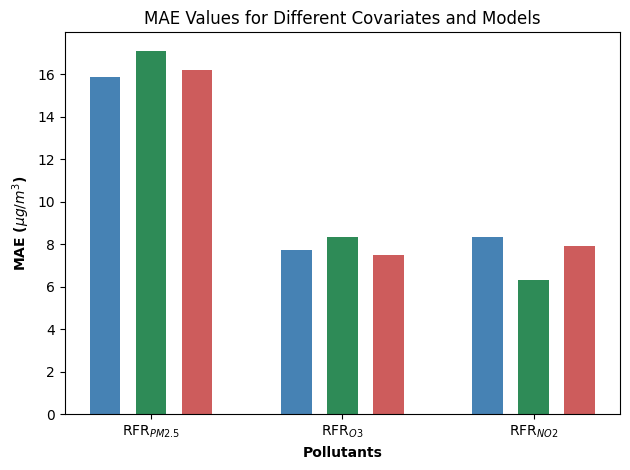

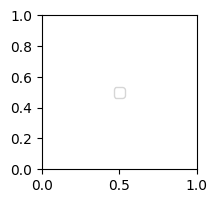

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['PM2.5', 'Ozone', 'NO2']
STC = [15.86, 7.73, 8.33]
PCC = [17.12, 8.33, 6.33]
CC = [16.19, 7.52, 7.92]

# Bar width
bar_width = 0.16  # Adjusted bar width

# Bar positions
r1 = np.arange(len(models))
r2 = [x + bar_width * 1.5 for x in r1]  # Increased gap
r3 = [x + bar_width * 3 for x in r1]    # Increased gap

# Create the plot
plt.bar(r1, STC, color='steelblue', width=bar_width, label='STC')
plt.bar(r2, PCC, color='seagreen', width=bar_width, label='PCC')
plt.bar(r3, CC, color='indianred', width=bar_width, label='CC')

# Add labels
plt.xlabel('Pollutants', fontweight='bold')
plt.ylabel('MAE ($\mu g/m^3$)', fontweight='bold')

# Update x-tick labels with subscript for RFR
plt.xticks([r + bar_width * 1.5 for r in range(len(models))], 
           [f'RFR$_{{PM2.5}}$', 'RFR$_{{O3}}$', 'RFR$_{{NO2}}$'])

# Title and legend
plt.title('MAE Values for Different Covariates and Models')

# Save the plot as tiff
plot_file_path = r'D:\Manoj_Honors\bar_plot_mae.tiff'  # Corrected file path
plt.tight_layout()
plt.savefig(plot_file_path, format='tiff')

# Save the legend as a separate tiff file
fig_legend = plt.figure(figsize=(2, 2))
plt.legend(['STC', 'PCC', 'CC'], loc='center')
legend_file_path = r'D:\Manoj_Honors\legend.tiff'  # Corrected file path
fig_legend.savefig(legend_file_path, format='tiff')

# Return the file paths for download
plot_file_path, legend_file_path


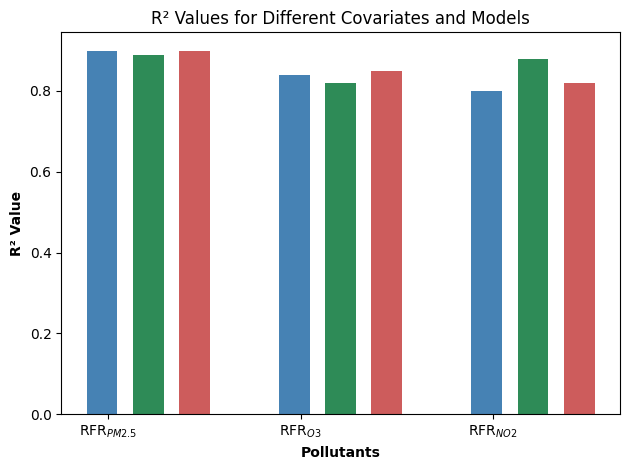

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['PM2.5', 'Ozone', 'NO2']
STC = [0.9, 0.84, 0.8]
PCC = [0.89, 0.82, 0.88]
CC = [0.9, 0.85, 0.82]

# Bar width
bar_width = 0.16  # Adjusted bar width

# Bar positions
r1 = np.arange(len(models))
r2 = [x + bar_width * 1.5 for x in r1]  # Increased gap
r3 = [x + bar_width * 3 for x in r1]    # Increased gap

# Create bars
plt.bar(r1, STC, color='steelblue', width=bar_width, label='STC')
plt.bar(r2, PCC, color='seagreen', width=bar_width, label='PCC')
plt.bar(r3, CC, color='indianred', width=bar_width, label='CC')

# Add labels
plt.xlabel('Pollutants', fontweight='bold')
plt.ylabel('R² Value', fontweight='bold')

# Update x-tick labels with subscript for RFR
plt.xticks([r + bar_width * 0.2 for r in range(len(models))], 
           [f'RFR$_{{PM2.5}}$', 'RFR$_{{O3}}$', 'RFR$_{{NO2}}$'])

plot_file_path = r'D:\Manoj_Honors\bar_plot_r2.tiff'  # Corrected file path
plt.title('R² Values for Different Covariates and Models')
plt.tight_layout()
plt.savefig(plot_file_path, format='tiff')
# Title and legend



In [26]:
df = pd.read_csv(r'D:\Manoj_Honors\Merged_Data_avg.csv')
print(df.columns)

Index(['Time', 'Station_ID', 'NO2', 'PM2.5', 'Ozone', 'Lat', 'Lon', 'Date',
       'Average_PM2.5_t-1', 'Average_Ozone_t-1', 'Average_NO2_t-1'],
      dtype='object')


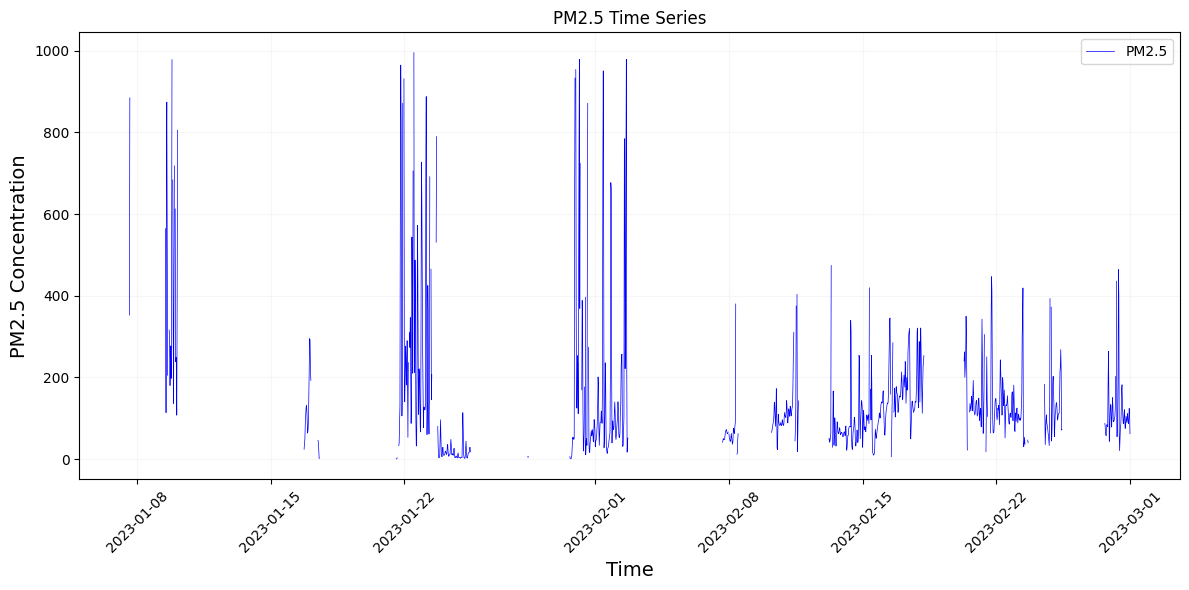

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = r'D:\Manoj_Honors\Merged_Data_avg.csv'
df = pd.read_csv(file_path)

# Convert 'Time' column to datetime format
df['Time'] = pd.to_datetime(df['Time'])

# Filter the data for Station_ID 16
station_16_data = df[df['Station_ID'] == 16]

# Filter for the specified time range
start_date = '2023-01-01'
end_date = '2023-03-01'
station_16_data = station_16_data[(station_16_data['Time'] >= start_date) & (station_16_data['Time'] <= end_date)]

# Sort by 'Time' to ensure the time series is in chronological order
station_16_data = station_16_data.sort_values(by='Time')

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(station_16_data['Time'], station_16_data['PM2.5'], label='PM2.5', color='blue', linewidth=0.5)

# Add titles and labels
plt.title('PM2.5 Time Series', fontsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='-', alpha=0.1)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()


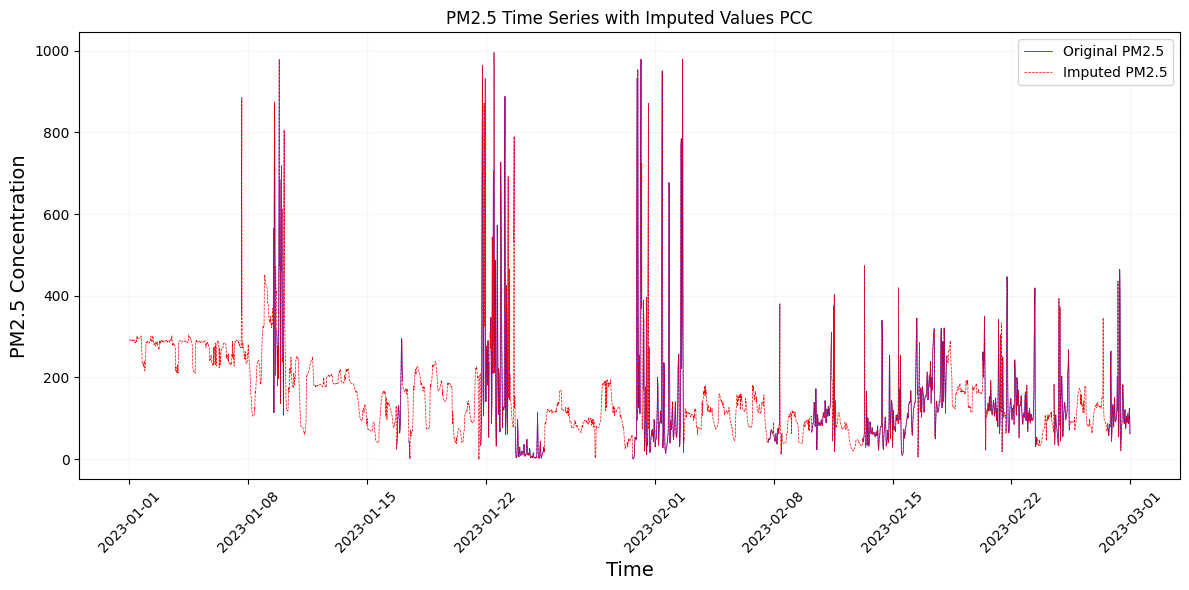

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Load the dataset
file_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'
df = pd.read_csv(file_path)

# Convert 'Time' column to datetime format and store in 'Original_Time'
df['Original_Time'] = pd.to_datetime(df['Time'])

# Create the UNIX timestamp and store it as 'Time'
df['Time'] = df['Original_Time'].values.astype('int64') / 10**9

# Filter the data for Station_ID 16
station_16_data = df[df['Station_ID'] == 16]

# Filter for the specified time range
start_date = '2023-01-01'
end_date = '2023-03-01'
station_16_data = station_16_data[(station_16_data['Original_Time'] >= start_date) & (station_16_data['Original_Time'] <= end_date)]

# Sort by 'Time' to ensure the time series is in chronological order
station_16_data = station_16_data.sort_values(by='Original_Time')

# Make a copy of the data
station_16_data_imputed = station_16_data.copy()

# Identify missing PM2.5 values
missing_pm25 = station_16_data_imputed['PM2.5'].isnull()

# Load the PCC model (assuming it's already trained and saved)
pcc_model_path = r'D:\Manoj_Honors\random_forest_model_PM2.5(PCC).pkl'
with open(pcc_model_path, 'rb') as file:
    pcc_model = pickle.load(file)

# Select relevant features for PCC model (modify as per actual features)
features = ['Time', 'Lat', 'Lon', 'NO2_prev_day', 'NO2_prev_week', 'Spatial_Avg_NO2', 'NO2', 
            'Ozone_prev_day', 'Ozone_prev_week', 'Spatial_Avg_Ozone', 'Ozone']  # Use the 'Time' UNIX timestamp

# Prepare the data for imputation (excluding the 'PM2.5' column itself)
X_impute = station_16_data_imputed[features]

# Impute missing PM2.5 values using the PCC model
station_16_data_imputed.loc[missing_pm25, 'PM2.5'] = pcc_model.predict(X_impute[missing_pm25])

# Plot the time series with imputed values in a different color
plt.figure(figsize=(12, 6))

# Plot original PM2.5 values
plt.plot(station_16_data['Original_Time'], station_16_data['PM2.5'], label='Original PM2.5', color='blue', linewidth=0.5)

# Plot imputed PM2.5 values
plt.plot(station_16_data_imputed['Original_Time'], station_16_data_imputed['PM2.5'], label='Imputed PM2.5', color='red', linewidth=0.5, linestyle='--')

# Add titles and labels
plt.title('PM2.5 Time Series with Imputed Values PCC', fontsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='-', alpha=0.1)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()


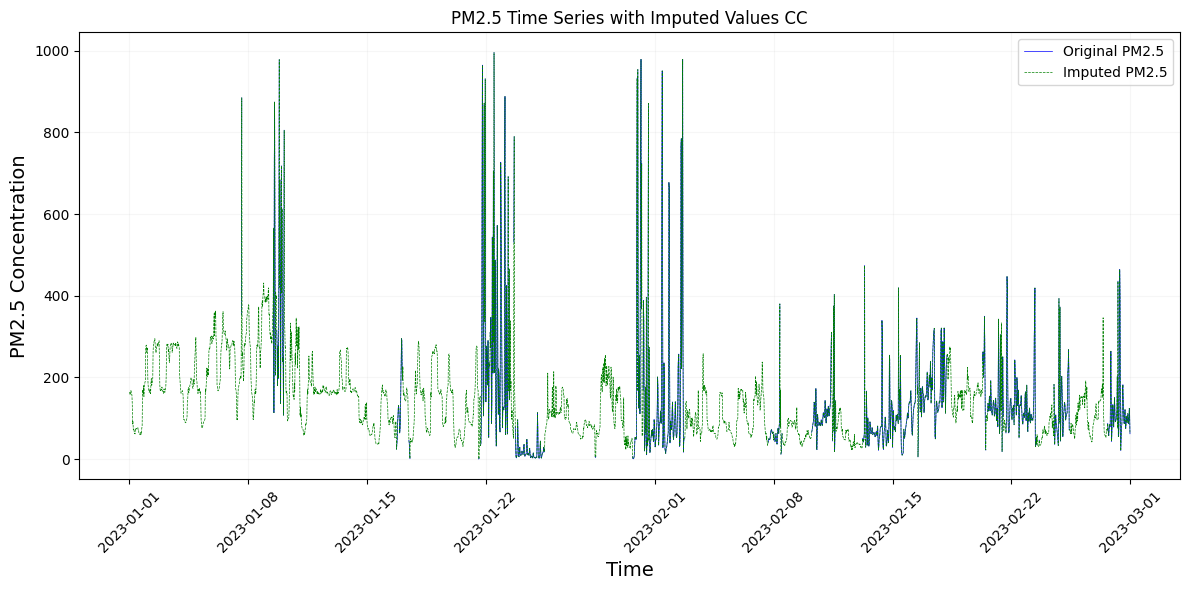

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Load the dataset
file_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'
df = pd.read_csv(file_path)

# Convert 'Time' column to datetime format and store in 'Original_Time'
df['Original_Time'] = pd.to_datetime(df['Time'])

# Create the UNIX timestamp and store it as 'Time'
df['Time'] = df['Original_Time'].values.astype('int64') / 10**9

# Filter the data for Station_ID 16
station_16_data = df[df['Station_ID'] == 16]

# Filter for the specified time range
start_date = '2023-01-01'
end_date = '2023-03-01'
station_16_data = station_16_data[(station_16_data['Original_Time'] >= start_date) & (station_16_data['Original_Time'] <= end_date)]

# Sort by 'Time' to ensure the time series is in chronological order
station_16_data = station_16_data.sort_values(by='Original_Time')

# Make a copy of the data
station_16_data_imputed = station_16_data.copy()

# Identify missing PM2.5 values
missing_pm25 = station_16_data_imputed['PM2.5'].isnull()

# Load the PCC model (assuming it's already trained and saved)
pcc_model_path = r'D:\Manoj_Honors\random_forest_model_PM2.5(CC).pkl'
with open(pcc_model_path, 'rb') as file:
    pcc_model = pickle.load(file)

# Select relevant features for PCC model (modify as per actual features)
features = ['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']  # Use the 'Time' UNIX timestamp

# Prepare the data for imputation (excluding the 'PM2.5' column itself)
X_impute = station_16_data_imputed[features]

# Impute missing PM2.5 values using the PCC model
station_16_data_imputed.loc[missing_pm25, 'PM2.5'] = pcc_model.predict(X_impute[missing_pm25])

# Plot the time series with imputed values in a different color
plt.figure(figsize=(12, 6))

# Plot original PM2.5 values
plt.plot(station_16_data['Original_Time'], station_16_data['PM2.5'], label='Original PM2.5', color='blue', linewidth=0.5)

# Plot imputed PM2.5 values
plt.plot(station_16_data_imputed['Original_Time'], station_16_data_imputed['PM2.5'], label='Imputed PM2.5', color='green', linewidth=0.5, linestyle='--')

# Add titles and labels
plt.title('PM2.5 Time Series with Imputed Values CC', fontsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='-', alpha=0.1)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()


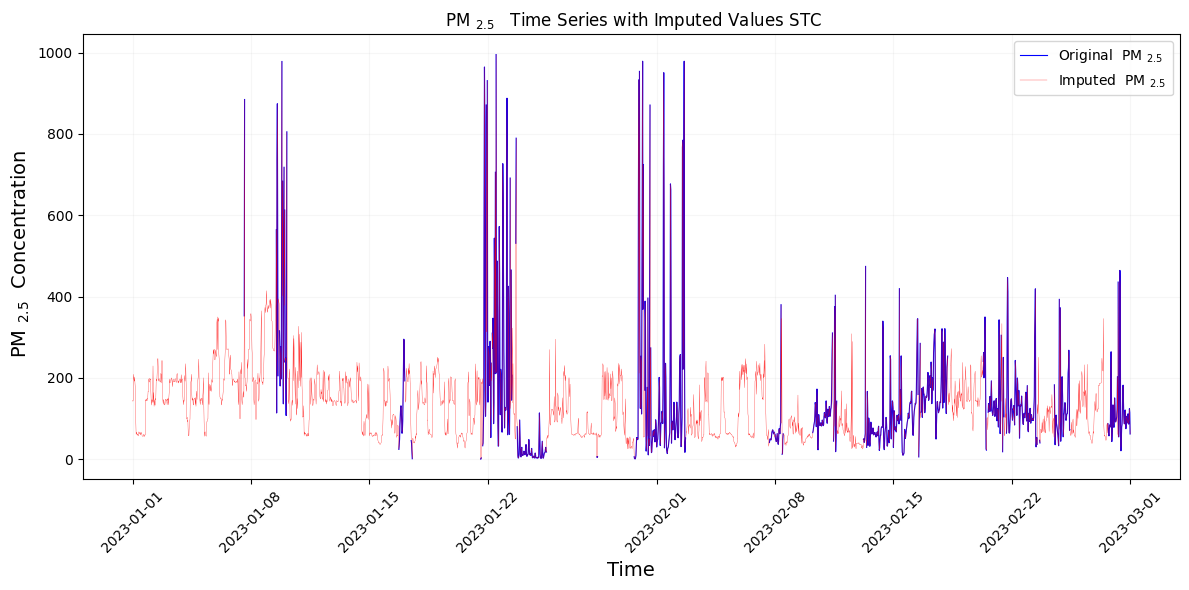

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Load the dataset
file_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'
df = pd.read_csv(file_path)

# Convert 'Time' column to datetime format and store in 'Original_Time'
df['Original_Time'] = pd.to_datetime(df['Time'])

# Create the UNIX timestamp and store it as 'Time'
df['Time'] = df['Original_Time'].values.astype('int64') / 10**9

# Filter the data for Station_ID 16
station_16_data = df[df['Station_ID'] == 16]

# Filter for the specified time range
start_date = '2023-01-01'
end_date = '2023-03-01'
station_16_data = station_16_data[(station_16_data['Original_Time'] >= start_date) & (station_16_data['Original_Time'] <= end_date)]

# Sort by 'Time' to ensure the time series is in chronological order
station_16_data = station_16_data.sort_values(by='Original_Time')

# Make a copy of the data
station_16_data_imputed = station_16_data.copy()

# Identify missing PM2.5 values
missing_pm25 = station_16_data_imputed['PM2.5'].isnull()

# Load the PCC model (assuming it's already trained and saved)
pcc_model_path = r'D:\Manoj_Honors\random_forest_model_PM2.5(STC).pkl'
with open(pcc_model_path, 'rb') as file:
    pcc_model = pickle.load(file)

# Select relevant features for PCC model (modify as per actual features)
features = ['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']  # Use the 'Time' UNIX timestamp

# Prepare the data for imputation (excluding the 'PM2.5' column itself)
X_impute = station_16_data_imputed[features]

# Impute missing PM2.5 values using the PCC model
station_16_data_imputed.loc[missing_pm25, 'PM2.5'] = pcc_model.predict(X_impute[missing_pm25])

# Plot the time series with imputed values in a different color
plt.figure(figsize=(12, 6))

# Plot original PM2.5 values
plt.plot(station_16_data['Original_Time'], station_16_data['PM2.5'], label='Original  PM $_{{2.5}}$ ', color='blue', linewidth=0.8)

# Plot imputed PM2.5 values
plt.plot(station_16_data_imputed['Original_Time'], station_16_data_imputed['PM2.5'], label='Imputed  PM $_{{2.5}}$ ', color='red', linewidth=0.2, linestyle='-')

# Add titles and labels
plt.title(' PM $_{{2.5}}$   Time Series with Imputed Values STC', fontsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel(' PM $_{{2.5}}$  Concentration', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='-', alpha=0.1)
plt.legend()
plt.tight_layout()

# Save the plot as a TIFF file
output_file = r'D:\Manoj_Honors\pm25_time_series_imputed.png'
plt.savefig(output_file, format='png', dpi=300)

# Show the plot
plt.show()



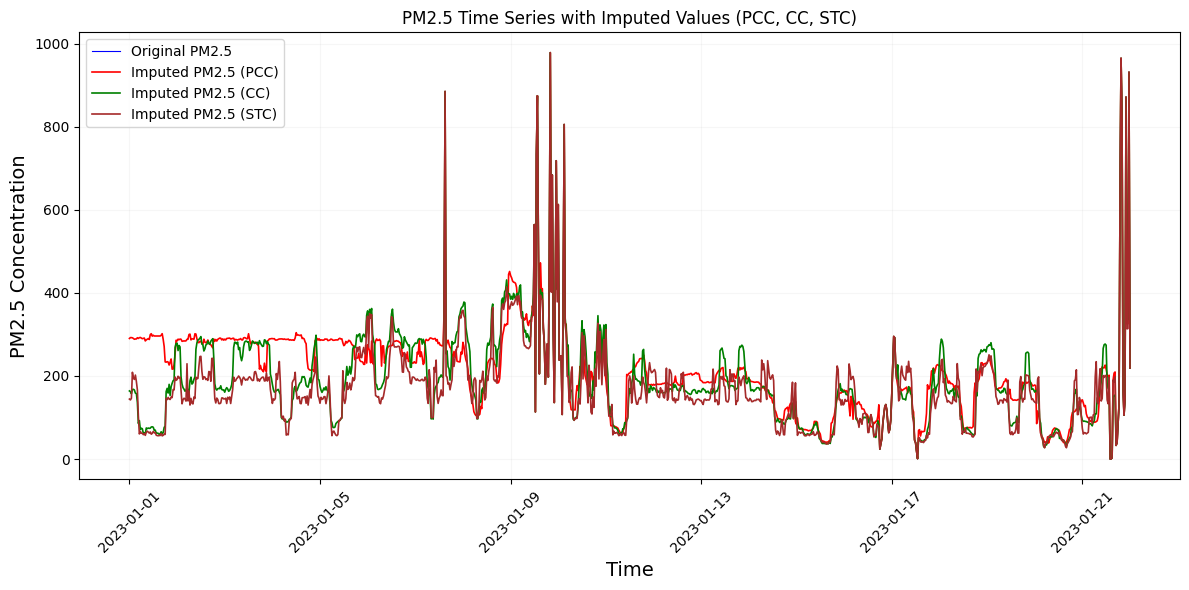

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Load the dataset
file_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'
df = pd.read_csv(file_path)

# Convert 'Time' column to datetime format and store in 'Original_Time'
df['Original_Time'] = pd.to_datetime(df['Time'])

# Create the UNIX timestamp and store it as 'Time'
df['Time'] = df['Original_Time'].values.astype('int64') / 10**9

# Filter the data for Station_ID 16
station_16_data = df[df['Station_ID'] == 16]

# Filter for the specified time range
start_date = '2023-01-01'
end_date = '2023-01-22'
station_16_data = station_16_data[(station_16_data['Original_Time'] >= start_date) & (station_16_data['Original_Time'] <= end_date)]

# Sort by 'Time' to ensure the time series is in chronological order
station_16_data = station_16_data.sort_values(by='Original_Time')

# Create subplots for all three models
plt.figure(figsize=(12, 6))

# Plot original PM2.5 values
plt.plot(station_16_data['Original_Time'], station_16_data['PM2.5'], label='Original PM2.5', color='blue', linewidth=0.8)

# PCC Model
station_16_data_imputed_pcc = station_16_data.copy()
missing_pm25_pcc = station_16_data_imputed_pcc['PM2.5'].isnull()
with open(r'D:\Manoj_Honors\random_forest_model_PM2.5(PCC).pkl', 'rb') as file:
    pcc_model = pickle.load(file)
features_pcc = ['Time', 'Lat', 'Lon', 'NO2_prev_day', 'NO2_prev_week', 'Spatial_Avg_NO2', 'NO2', 
                'Ozone_prev_day', 'Ozone_prev_week', 'Spatial_Avg_Ozone', 'Ozone']
X_impute_pcc = station_16_data_imputed_pcc[features_pcc]
station_16_data_imputed_pcc.loc[missing_pm25_pcc, 'PM2.5'] = pcc_model.predict(X_impute_pcc[missing_pm25_pcc])
plt.plot(station_16_data_imputed_pcc['Original_Time'], station_16_data_imputed_pcc['PM2.5'], label='Imputed PM2.5 (PCC)', color='red', linewidth=1.2)

# CC Model
station_16_data_imputed_cc = station_16_data.copy()
missing_pm25_cc = station_16_data_imputed_cc['PM2.5'].isnull()
with open(r'D:\Manoj_Honors\random_forest_model_PM2.5(CC).pkl', 'rb') as file:
    pcc_model_cc = pickle.load(file)
features_cc = ['Time', 'Lat', 'Lon', 'NO2_prev_day', 'NO2_prev_week', 'Spatial_Avg_NO2', 'NO2', 
               'Ozone', 'Ozone_prev_day', 'Ozone_prev_week', 'Spatial_Avg_Ozone', 'PM2.5_prev_day', 
               'PM2.5_prev_week', 'Spatial_Avg_PM2.5']
X_impute_cc = station_16_data_imputed_cc[features_cc]
station_16_data_imputed_cc.loc[missing_pm25_cc, 'PM2.5'] = pcc_model_cc.predict(X_impute_cc[missing_pm25_cc])
plt.plot(station_16_data_imputed_cc['Original_Time'], station_16_data_imputed_cc['PM2.5'], label='Imputed PM2.5 (CC)', color='green', linewidth=1.2)

# STC Model
station_16_data_imputed_stc = station_16_data.copy()
missing_pm25_stc = station_16_data_imputed_stc['PM2.5'].isnull()
with open(r'D:\Manoj_Honors\random_forest_model_PM2.5(STC).pkl', 'rb') as file:
    pcc_model_stc = pickle.load(file)
features_stc = ['Time', 'Lat', 'Lon', 'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5']
X_impute_stc = station_16_data_imputed_stc[features_stc]
station_16_data_imputed_stc.loc[missing_pm25_stc, 'PM2.5'] = pcc_model_stc.predict(X_impute_stc[missing_pm25_stc])
plt.plot(station_16_data_imputed_stc['Original_Time'], station_16_data_imputed_stc['PM2.5'], label='Imputed PM2.5 (STC)', color='brown', linewidth=1.2)

# Add titles and labels
plt.title('PM2.5 Time Series with Imputed Values (PCC, CC, STC)', fontsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='-', alpha=0.1)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

# Drop rows with missing values
all_available = all_available.dropna()

# Prepare lists to store metrics for each station
metrics = []

# Loop through each station
stations = all_available['Station_ID'].unique()
for station in stations:
    station_data = all_available[all_available['Station_ID'] == station]

    # Features and target
    X = station_data[['Time', 'Lat', 'Lon', 'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5']]
    y = station_data['PM2.5']

    # Convert 'Time' to numeric if it's in datetime format
    X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

    # Train-test split (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

    # Initialize the Random Forest model
    rf = RandomForestRegressor(n_estimators=100, random_state=12)

    # Train the model
    rf.fit(X_train, y_train)

    # Predict on the test set
    y_pred = rf.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    # Store metrics for this station
    metrics.append({
        'Station_ID': station,
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'NRMSE': nrmse
    })

# Convert metrics to a DataFrame
metrics_df = pd.DataFrame(metrics)

# Save metrics to a CSV file
output_file = 'D:\Manoj_Honors\station_metrics.csv'
metrics_df.to_csv(output_file, index=False)

print(f"Metrics saved to {output_file}")


In [31]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

# Drop rows with missing values
all_available = all_available.dropna()

# Grouped train-test split: 80% training and 20% testing for each station
train_data = []
test_data = []

stations = all_available['Station_ID'].unique()
for station in stations:
    station_data = all_available[all_available['Station_ID'] == station]
    station_train = station_data.sample(frac=0.8, random_state=12)
    station_test = station_data.drop(station_train.index)
    
    train_data.append(station_train)
    test_data.append(station_test)

# Combine station-wise splits
train_data = pd.concat(train_data)
test_data = pd.concat(test_data)

# Features and target
X_train = train_data[['Time', 'Lat', 'Lon', 'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5']]
y_train = train_data['PM2.5']

X_test = test_data[['Time', 'Lat', 'Lon', 'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5']]
y_test = test_data['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X_train['Time'] = pd.to_datetime(X_train['Time'], errors='coerce').astype('int64') // 10**9
X_test['Time'] = pd.to_datetime(X_test['Time'], errors='coerce').astype('int64') // 10**9

# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Train the model
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Calculate overall metrics
overall_mse = mean_squared_error(y_test, y_pred)
overall_mae = mean_absolute_error(y_test, y_pred)
overall_r2 = r2_score(y_test, y_pred)
overall_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
overall_nrmse = np.sqrt(overall_mse) / (y_test.max() - y_test.min())

print(f"Overall Metrics:")
print(f"Mean Squared Error: {round(overall_mse, 2)}")
print(f"Mean Absolute Error: {round(overall_mae, 2)}")
print(f"R^2 Score: {round(overall_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(overall_mape, 2)}%")
print(f"Normalized RMSE: {round(overall_nrmse, 4)}")

# Calculate individual station metrics
station_metrics = []

for station in stations:
    station_test_data = test_data[test_data['Station_ID'] == station]
    station_X_test = station_test_data[['Time', 'Lat', 'Lon', 'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5']]
    station_y_test = station_test_data['PM2.5']
    
    station_X_test['Time'] = pd.to_datetime(station_X_test['Time'], errors='coerce').astype('int64') // 10**9
    
    station_y_pred = rf.predict(station_X_test)
    
    mse = mean_squared_error(station_y_test, station_y_pred)
    mae = mean_absolute_error(station_y_test, station_y_pred)
    r2 = r2_score(station_y_test, station_y_pred)
    mape = np.mean(np.abs((station_y_test - station_y_pred) / station_y_test)) * 100
    nrmse = np.sqrt(mse) / (station_y_test.max() - station_y_test.min())
    
    station_metrics.append({
        'Station_ID': station,
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'NRMSE': nrmse
    })

# Save station-wise metrics to a CSV file
station_metrics_df = pd.DataFrame(station_metrics)
station_metrics_df.to_csv('D:\Manoj_Honors\station_metrics.csv', index=False)

print("Station-wise metrics saved to 'station_metrics.csv'")


<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:92: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:92: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23836\2678567975.py:7: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23836\2678567975.py:92: SyntaxWarning: invalid escape sequence '\M'
  station_metrics_df.to_csv('D:\Manoj_Honors\station_metrics.csv', index=False)
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23836\2678567975.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Time'] = pd.to_datetime(X_train['Time']

Overall Metrics:
Mean Squared Error: 742.08
Mean Absolute Error: 15.65
R^2 Score: 0.9
Mean Absolute Percentage Error: 47.7%
Normalized RMSE: 0.0273


C:\Users\Faculty\AppData\Local\Temp\ipykernel_23836\2678567975.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  station_X_test['Time'] = pd.to_datetime(station_X_test['Time'], errors='coerce').astype('int64') // 10**9
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23836\2678567975.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  station_X_test['Time'] = pd.to_datetime(station_X_test['Time'], errors='coerce').astype('int64') // 10**9
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23836\2678567975.py:71

Station-wise metrics saved to 'station_metrics.csv'


C:\Users\Faculty\AppData\Local\Temp\ipykernel_23836\2678567975.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  station_X_test['Time'] = pd.to_datetime(station_X_test['Time'], errors='coerce').astype('int64') // 10**9


In [37]:
import pandas as pd

# Load station metrics data
metrics_df = pd.read_csv(r'D:\Manoj_Honors\station_metrics.csv')

# Load the main data containing Station_ID, Lat, and Lon
main_data = pd.read_csv(r'D:\Manoj_Honors\Merged_Data.csv')

# Extract unique Station_ID, Lat, and Lon from the main dataset
location_data = main_data[['Station_ID', 'Lat', 'Lon']].drop_duplicates()

# Merge metrics_df with location_data based on Station_ID
metrics_with_locations = pd.merge(metrics_df, location_data, on='Station_ID', how='left')

# Save the updated DataFrame to a CSV
metrics_with_locations.to_csv(r'D:\Manoj_Honors\station_metrics_with_lat_lon.csv', index=False)

print("Lat and Lon columns added successfully.")


Lat and Lon columns added successfully.


<>:6: SyntaxWarning: invalid escape sequence '\M'
<>:6: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23836\208146755.py:6: SyntaxWarning: invalid escape sequence '\M'
  metrics_df = pd.read_csv('D:\Manoj_Honors\station_metrics_with_lat_lon.csv')


Index(['Station_ID', 'MSE', 'MAE', 'R2', 'MAPE', 'NRMSE', 'Lat', 'Lon'], dtype='object')


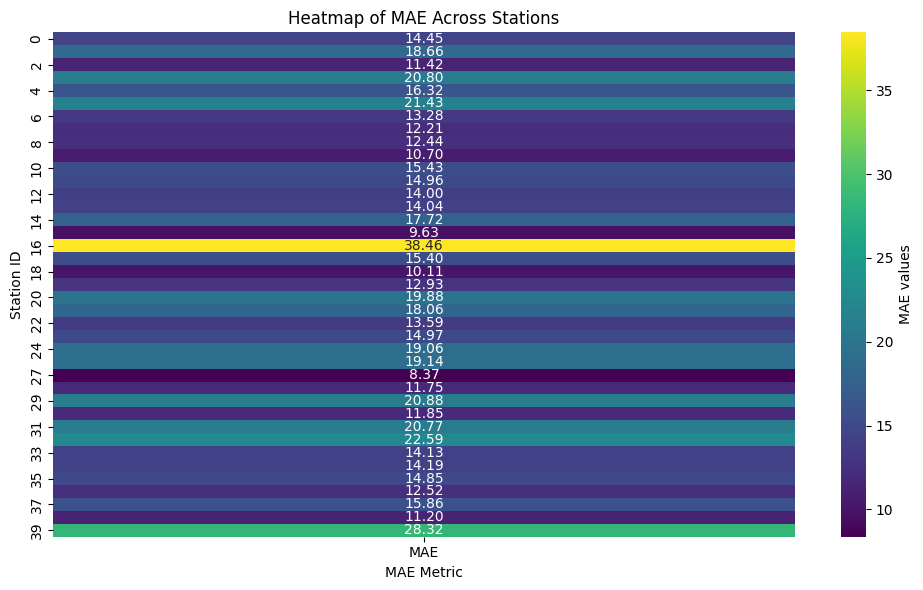

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the station metrics CSV
metrics_df = pd.read_csv('D:\Manoj_Honors\station_metrics_with_lat_lon.csv')
print(metrics_df.columns)
# Sort the data by Station_ID for ordered visualization
metrics_df = metrics_df.sort_values(by='Station_ID')

# Select only the R² metric
r2_data = metrics_df.set_index('Station_ID')[['MAE']]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(r2_data, annot=True, cmap='viridis', fmt=".2f", cbar_kws={'label': 'MAE values'})
plt.title('Heatmap of MAE Across Stations')
plt.ylabel('Station ID')
plt.xlabel('MAE Metric')
plt.tight_layout()
plt.show()



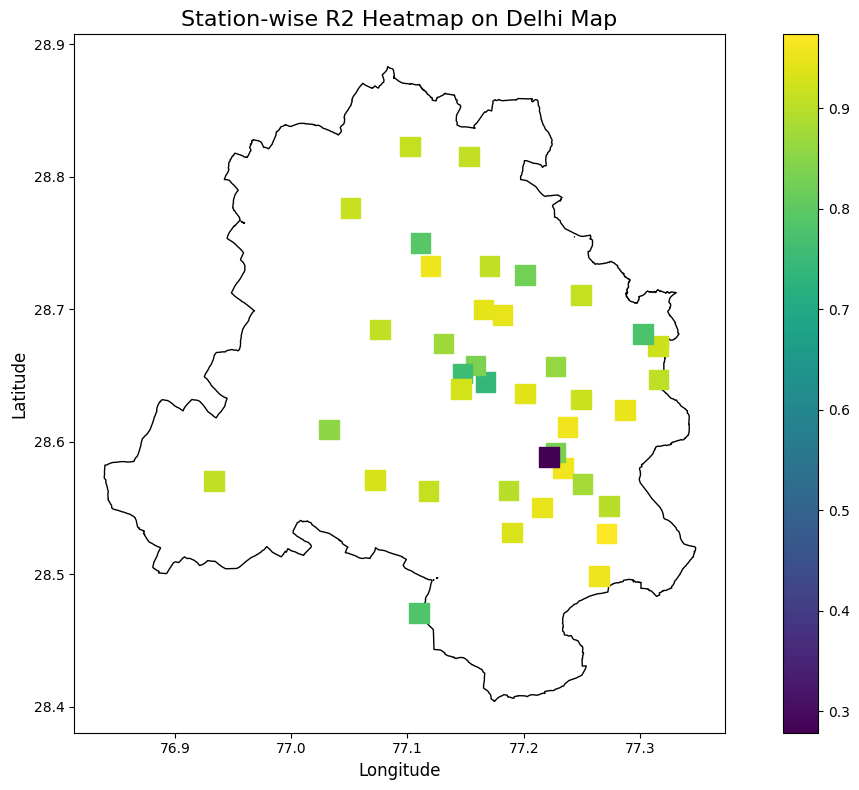

In [46]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Load the station metrics CSV
metrics_df = pd.read_csv(r'D:\Manoj_Honors\station_metrics_with_lat_lon.csv')

# Load the Delhi shapefile
delhi_shape = gpd.read_file(r'D:\Manoj_Honors\Delhi Map\Delhi_Boundary.shp')

# Create a GeoDataFrame from the station data
stations_gdf = gpd.GeoDataFrame(
    metrics_df,
    geometry=gpd.points_from_xy(metrics_df['Lon'], metrics_df['Lat']),
    crs=delhi_shape.crs
)

# Normalize the MAE values for color mapping
norm = Normalize(vmin=metrics_df['R2'].min(), vmax=metrics_df['R2'].max())

# Plot the Delhi shapefile
fig, ax = plt.subplots(figsize=(12, 8))

# Change the background color to white
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot the Delhi boundary
delhi_shape.plot(ax=ax, color='white', edgecolor='black')

# Add the stations with square markers and color representing MAE
stations_gdf.plot(
    ax=ax,
    column='R2',
    cmap='viridis',
    legend=True,
    marker='s',  # Square marker
    markersize=200,
    norm=norm
)

# Add a title and labels
plt.title('Station-wise R2 Heatmap on Delhi Map', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.tight_layout()

# Save the plot as a TIFF file
output_path = r'D:\Manoj_Honors\Station_R2_Heatmap.tiff'
plt.savefig(output_path, format='tiff', dpi=300)

# Show the plot
plt.show()
